# Definition of classes

In [ ]:
import torch
from typing import Union, Tuple
from mlcolvar.core.loss.utils.smart_derivatives import SmartDerivatives
from mlcolvar.utils._code import scatter_sum

class GeneratorLoss_graph(torch.nn.Module):
    """Computes the loss function to learn a representation for the resolvent of the infinitesimal generator"""

    def __init__(self,
                 r: int, 
                 eta: float, 
                 friction: torch.Tensor, 
                 alpha: float,
                 cell: float = None,  
                 descriptors_derivatives: Union[SmartDerivatives, torch.Tensor] = None,
                 n_dim: int = 3,
                 u_stat: bool = True,
                 softmax_postproc=True,
                 ):
        """Computes the loss to learn a representation on which the resolvent of the infinitesimal generator can be learned

        Parameters
        ----------
        r : int
            Number of eigenfunctions wanted, i.e., number of outputs of model.
        eta : float
            Hyperparameter for the shift to define the resolvent, i.e., $(\eta I-_mathcal{L})^{-1}$
        friction : torch.Tensor
            Langevin friction, i.e., $\sqrt{k_B*T/(gamma*m_i)}$
        alpha : float
            Hyperparamer that scales the contribution of orthonormality loss to the total loss, i.e., L = L_ef + alpha*L_ortho
        cell : float, optional
            CUBIC cell size length, used to scale the positions from reduce coordinates to real coordinates, by default None 
        descriptors_derivatives : Union[SmartDerivatives, torch.Tensor], optional
            Derivatives of descriptors wrt atomic positions (if used) to speed up calculation of gradients, by default None. 
            Can be either:
                - A `SmartDerivatives` object to save both memory and time, see also mlcolvar.core.loss.committor_loss.SmartDerivatives
                - A torch.Tensor with the derivatives to save time, memory-wise could be less efficient
        ref_idx: torch.Tensor, optional
            Reference indeces for the unshuffled dataset for properly handling batching/splitting/shuffling
            when descriptors derivatives are provided, by default None. 
            Ref_idx can be generated automatically using SmartDerivatives or by setting create_ref_idx=True when initializing a DictDataset.
            See also mlcolvar.core.loss.utils.smart_derivatives.SmartDerivatives
        n_dim : int
            Number of dimensions, by default 3.
        u_stat : bool
            Do we use U-statistics to compute the loss
        """
        super().__init__()

        self.eta = eta
        self.register_buffer("friction", friction)
        self.lambdas = torch.nn.Parameter(10 * torch.randn(r), requires_grad=True)
        self.alpha = alpha
        self.cell = cell
        self.descriptors_derivatives = descriptors_derivatives
        self.n_dim = n_dim
        self.u_stat=u_stat
        self.softmax_postproc=softmax_postproc

    def forward(self,
                input : torch.Tensor,
                output : torch.Tensor, 
                weights : torch.Tensor,
                ref_idx : torch.Tensor = None
                ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        
        # preload descriptors matrix on device
        if isinstance(self.descriptors_derivatives, torch.Tensor):
            if self.descriptors_derivatives.device != input.device:
                self.descriptors_derivatives = self.descriptors_derivatives.to(input.device)

        return generator_loss(input=input,
                              output=output,
                              weights=weights,
                              eta=self.eta,
                              alpha=self.alpha,
                              friction=self.friction,
                              lambdas=self.lambdas,
                              cell=self.cell,
                              descriptors_derivatives=self.descriptors_derivatives,
                              ref_idx=ref_idx,
                              n_dim=self.n_dim,
                              u_stat=self.u_stat,
                              softmax_postproc=self.softmax_postproc
                              )


# TODO check that maybe we can replace this by the one from deepTICA
def compute_covariance(X, weights):
    n = X.size(0)
    pre_factor = n / (n - 1)
    if X.ndim == 2:
        return pre_factor * (
            torch.einsum("ij,ik,i->jk", X, X, weights) / n
        )  # (X.T @ X / n - mean @ mean.T)
    else:
        return pre_factor * (torch.einsum("ijk,ilk,i->jl", X, X, weights) / n)


def generator_loss(input : torch.Tensor,
                   output : torch.Tensor,
                   weights : torch.Tensor,
                   eta : float,
                   alpha : float,
                   friction : torch.Tensor,
                   lambdas : torch.Tensor,
                   cell : float = None,
                   descriptors_derivatives : Union[SmartDerivatives, torch.Tensor] = None,
                   ref_idx : torch.Tensor = None,
                   n_dim : int = 3,
                   u_stat : bool = True,
                   softmax_postproc=True,
                   ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Optimizes r functions to be the representation on which the resolvent of the infinitesimal generator can be learned

    Parameters
    ----------
    input : torch.Tensor
        Input of the (set of) neural networks
    output : torch.Tensor
        Output of the (set of) neural networks
    weights : torch.Tensor
        Statistical weights of the samples, this could be from reweighting.
    eta : float
        Hyperparameter for the shift to define the resolvent, i.e., $(\eta I-_mathcal{L})^{-1}$
    alpha : float
        Hyperparamer that scales the contribution of orthonormality loss to the total loss, i.e., L = L_ef + alpha*L_ortho
    friction : torch.Tensor
        Langevin friction, i.e., $\sqrt{k_B*T/(gamma*m_i)}$
    lambdas : torch.Tensor
        Trainable parameters. After training, they should correspond to the resolvent eigenvalues.
    cell : float, optional
        CUBIC cell size length, used to scale the positions from reduce coordinates to real coordinates, by default None
    descriptors_derivatives : Union[SmartDerivatives, torch.Tensor], optional
        Derivatives of descriptors wrt atomic positions (if used) to speed up calculation of gradients, by default None. 
        Can be either:
            - A `SmartDerivatives` object to save both memory and time, see also mlcolvar.core.loss.committor_loss.SmartDerivatives
            - A torch.Tensor with the derivatives to save time, memory-wise could be less efficient
    ref_idx: torch.Tensor, optional
        Reference indeces for the unshuffled dataset for properly handling batching/splitting/shuffling
        when descriptors derivatives are provided, by default None. 
        Ref_idx can be generated automatically using SmartDerivatives or by setting create_ref_idx=True when initializing a DictDataset.
        See also mlcolvar.core.loss.utils.smart_derivatives.SmartDerivatives
    n_dim : int
        Number of dimensions, by default 3.
    u_stat : bool
        Do we use U-statistics to compute the loss

    Returns
    -------
    Tuple[torch.Tensor, torch.Tensor, torch.Tensor]
        Total loss, eigenfunctions loss, orthonormality loss 
    """    
    if descriptors_derivatives is not None and ref_idx is None:
        raise ValueError ("Descriptors derivatives need reference indeces from the dataset! Use a dataset with the ref_idx, see docstrign for details")

    # ------------------------ SETUP ------------------------
    # get correct device
    

    # move and process lambdas to device
    
    if isinstance(input, torch_geometric.data.batch.Batch):
        _is_graph_data = True
        batch = torch.clone(input['batch'])
        node_types = torch.where(input['node_attrs'])[1]#last one corresponds to yes or no it is a secondary structure
        input = input['positions']
        device = input.device

    else:
        device = input.device
        mask_var_batches = torch.ones(weights.shape[0]).to(device)
        _is_graph_data = False
    
    lambdas = lambdas.to(device)
    diag_lamb = torch.diag(lambdas**2)
    if softmax_postproc:
        diag_lamb = torch.block_diag(diag_lamb, torch.tensor(1/eta+1e-6,device=device).unsqueeze(0))
        one_column = torch.ones((output.shape[0],1),device=device)
        output = torch.cat((output,one_column),dim=1)
    # get number of outputs and sample sizes
    r = output.shape[1]
    sample_size = output.shape[0] // 2
    
    # expand friction tensor
    if _is_graph_data:

        friction = friction[node_types].unsqueeze(1).unsqueeze(2)
    else:
        friction = friction.repeat_interleave(n_dim) 
    # ------------------------ GRADIENTS ------------------------    
    # compute gradients of output wrt to the input iterating on the outputs
    grad_outputs = torch.ones(len(output), device=device)
    gradient = torch.stack([torch.autograd.grad(outputs=output[:, idx],
                                                inputs=input,
                                                grad_outputs=grad_outputs, 
                                                retain_graph=True, 
                                                create_graph=True)[0] for idx in range(r)
                            ], dim=2)
    
    
    # in case the input is not positions but descriptors, we need to correct the gradients up to the positions
    # --> If we pass a SmartDerivative object that takes the nonzero elements of the matrix d_desc/d_pos
    if isinstance(descriptors_derivatives, SmartDerivatives):
        gradient_positions = descriptors_derivatives(gradient, ref_idx).view(input.shape[0], -1, r)
    
    # --> If we directly pass the matrix d_desc/d_pos
    elif isinstance(descriptors_derivatives, torch.Tensor): 
        descriptors_derivatives = descriptors_derivatives.to(device)
        gradient_positions = torch.einsum("bdo,badx->baxo", gradient, descriptors_derivatives[ref_idx]).contiguous()
        gradient_positions = gradient_positions.view(input.shape[0],  # number of entries
                                                        descriptors_derivatives.shape[1] * 3, # number of atoms * 3 
                                                        output.shape[-1] # number of outputs
                                                        )
        
    # If the input was already positions
    else:
        gradient_positions = gradient 


    if r==1:
        gradient_positions = gradient_positions.unsqueeze(-1)

    # this is to make the following computation easier to write
    gradient_positions = gradient_positions.transpose(2,1).contiguous()
    if cell is not None:
        gradient_positions /= cell.repeat_interleave(gradient_positions.shape[-1]//n_dim)
    try:
        gradient_positions = gradient_positions * torch.sqrt(friction)
    except RuntimeError as e:
        raise RuntimeError(e, """[HINT]: Is you system in 3 dimension? By default the code assumes so, if it's not the case change the n_dim key to the right dimensionality.""")
    if _is_graph_data:
        gradient_positions = torch.einsum("ikd,ild->ikl",gradient_positions, gradient_positions)
        gradient_positions = scatter_sum(gradient_positions, batch,dim=0)
    # ------------------------ COVARIANCES ------------------------
    if u_stat:
        first = slice(0, sample_size)
        second = slice(sample_size, None)

        # In order to have unbiased estimation, we split the dataset in two chunks
        weights_X, weights_Y = weights[first], weights[second]
        #print(batch)
        gradient_X, gradient_Y = gradient_positions[first], gradient_positions[second]
        psi_X, psi_Y = output[first], output[second]
        #print(f"Weights X {weights_X.shape} \n Weights_Y {weights_Y.shape} \n psi_X {psi_X.shape} \n psi_Y {psi_Y.shape} \n {gradient_X.shape} \n {gradient_Y.shape} \n {weights[mask_var_batches_X]}")

        # compute covariances
        cov_X = compute_covariance(psi_X, weights_X)
        cov_Y = compute_covariance(psi_Y, weights_Y)
        if _is_graph_data:
            dcov_X=torch.einsum("ikl,i->kl",gradient_X, weights_X) / gradient_X.shape[0]
            dcov_Y=torch.einsum("ikl,i->kl",gradient_Y, weights_Y) / gradient_Y.shape[0]
        else:
            dcov_X = compute_covariance(gradient_X, weights_X)
            dcov_Y = compute_covariance(gradient_Y, weights_Y)

        # action of shifted generator on the two chunks
        W1 = ( cov_X + dcov_X / eta) 
        W2 = ( cov_Y + dcov_Y / eta) 



        loss_1 = 0.5*torch.einsum('i,ij,j,ji->',
                                  diag_lamb.diag(),W1,diag_lamb.diag(),W2)
        loss_1 += 0.5*torch.einsum('i,ij,j,ji->',
                                   diag_lamb.diag(),W2,diag_lamb.diag(),W1)
        
        loss_2 = - weights_Y.mean()*(torch.diagonal(cov_X) * diag_lamb).sum()
        loss_2 -= weights_X.mean()*(torch.diagonal(cov_Y) * diag_lamb).sum()
        
        #compute ortho-normality term || U^*U - I||_F^2 + || V^*V - I||_F^2, split the batch for uniased estiamtion
        loss_3 = torch.einsum('ij,ji->',
                            W1,W2)
        loss_3 -= torch.mean(weights_X)*torch.diagonal(W2).sum()
        loss_3 -= torch.mean(weights_Y)*torch.diagonal(W1).sum()
        loss_3 += psi_X.shape[1]*torch.mean(weights_X)*torch.mean(weights_Y)         

        # ------------------------ COMPUTE LOSSES ------------------------
    else:
        print("NOT IMPLEMENTED YET")
    # combine
    loss = (loss_1+loss_2+alpha*loss_3)

    return loss, (loss_1+loss_2).detach(), alpha*loss_3.detach()


In [3]:
from mlcolvar.data import DictDataset
def compute_covariances(input,output,weights,r,friction,n_dim=3,descriptors_derivatives : Union[SmartDerivatives, torch.Tensor] = None, ref_idx=None):
    if isinstance(input, torch_geometric.data.batch.Batch):
        _is_graph_data = True
        batch = torch.clone(input['batch'])
        node_types = torch.where(input['node_attrs'])[1]
        input = input['positions']
        device = input.device
    else:
        _is_graph_data=False
    device = input.device

    # check output and r
    if output.shape[-1] != r:
        raise ValueError ( 
            f"The number of eigenfunctions to compute (r) must match the number of outputs from the model! Found r:{r} and output.shape:{output.shape}"
            )
        
    one_column = torch.ones((output.shape[0],1),device=device)
    output = torch.cat((output,one_column),dim=1)
    # expand friction tensor
    if _is_graph_data:
        friction = friction[node_types].unsqueeze(1).unsqueeze(2)
    else:
        friction = friction = friction.unsqueeze(-1).repeat((1, n_dim)).ravel()
    # ------------------------ GRADIENTS ------------------------    
    # compute gradients of output wrt to the input iterating on the outputs
    grad_outputs = torch.ones(len(output), device=device)
    gradient = torch.stack([torch.autograd.grad(outputs=output[:, idx],
                                                inputs=input,
                                                grad_outputs=grad_outputs, 
                                                retain_graph=True, 
                                                create_graph=True)[0] for idx in range(r+1)
                            ], dim=2)
    
    # in case the input is not positions but descriptors, we need to correct the gradients up to the positions
    # --> If we pass a SmartDerivative object that takes the nonzero elements of the matrix d_desc/d_pos
    if isinstance(descriptors_derivatives, SmartDerivatives):
        gradient_positions = descriptors_derivatives(gradient, ref_idx).reshape(input.shape[0], -1, r+1)
    
    # --> If we directly pass the matrix d_desc/d_pos
    elif isinstance(descriptors_derivatives, torch.Tensor): 
        descriptors_derivatives = descriptors_derivatives.to(device)
        gradient_positions = torch.einsum("bdo,badx->baxo", gradient, descriptors_derivatives)
        gradient_positions = gradient_positions.reshape(input.shape[0],  # number of entries
                                                        descriptors_derivatives.shape[1] * 3, # number of atoms * 3 
                                                        output.shape[-1] # number of outputs
                                                        )
        
    # If the input was already positions
    else:
        gradient_positions = gradient

    

    if r==1:
        gradient_positions = gradient_positions.unsqueeze(-1)

    # this is to make the following computation easier to write
    gradient_positions = gradient_positions.swapaxes(2,1)
    #if cell is not None:
    #    gradient_positions /= cell.repeat_interleave(gradient_positions.shape[-1]//n_dim)
    # multiply by friction

    try:
        gradient_positions = gradient_positions * torch.sqrt(friction)
    except RuntimeError as e:
        raise RuntimeError(e, """[HINT]: Is you system in 3 dimension? By default the code assumes so, if it's not the case change the n_dim key to the right dimensionality.""")

    if _is_graph_data:
        gradient_positions = torch.einsum("ikd,ild->ikl",gradient_positions, gradient_positions)
        gradient_positions = scatter_sum(gradient_positions, batch,dim=0)
        dcov_X = torch.einsum("ikl,i->kl",gradient_positions,weights)
    else:
        dcov_X = torch.einsum("ijk,ilk,i->jl", gradient_positions, gradient_positions, weights) 
    # ------------------------ COVARIANCES ------------------------
    # Compute covariances
    cov_X = torch.einsum("ik,il,i->kl",output,output,weights)
    del gradient_positions
    del gradient
    return cov_X.detach(), dcov_X.detach() 


def compute_eigenfunctions_new(dataset : DictDataset,
                           forward_call,
                           r : int,
                           eta : float,
                           friction : torch.Tensor,
                           cell: float = None,
                           tikhonov_reg : float = 1e-4,
                           descriptors_derivatives : Union[SmartDerivatives, torch.Tensor] = None,
                           n_dim : int = 3,
                           batch_size=None,
                           is_graph=False,
                           ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Computes eigenfunctions and eigenvalues from a learned representation.

    This function estimates the eigenfunctions and eigenvalues of the infinitesimal generator
    associated with the Langevin process. The eigenvalues are computed using a resolvent approach,
    where `evals` relate to the generator's eigenvalues as: `lambda = eta - 1/evals`.

    Parameters
    ----------
    input : torch.Tensor
        Input of the model
    output : torch.Tensor
        Output containing the learned representation of the data, i.e., output of the (set of) neural networks
    weights : torch.Tensor
        Statistical weights of the samples, this could be from reweighting.
    r : int
        Number of eigenfunctions to compute.
    eta : float
        Hyperparameter for the shift to define the resolvent, i.e., $(\eta I-_mathcal{L})^{-1}$
    friction : torch.Tensor
        Langevin friction, i.e., $\sqrt{k_B*T/(gamma*m_i)}$
    cell : float, optional
        CUBIC cell size length, used to scale the positions from reduce coordinates to real coordinates, by default None
    tikhonov_reg : float, optional
        Hyperparameter for the regularization of the inverse (Ridge regression parameter), by default 1e-4
    descriptors_derivatives : Union[SmartDerivatives, torch.Tensor], optional
        Derivatives of descriptors wrt atomic positions (if used) to speed up calculation of gradients, by default None. 
        Can be either:
            - A `SmartDerivatives` object to save both memory and time, see also mlcolvar.core.loss.committor_loss.SmartDerivatives
            - A torch.Tensor with the derivatives to save time, memory-wise could be less efficient
    n_dim : int
        Number of dimensions, by default 3.

    Returns
    -------
    Tuple[torch.Tensor, torch.Tensor, torch.Tensor]
        g : torch.Tensor, shape (N, r)
            The computed eigenfunctions evaluated at each data point.
        lambdas : torch.Tensor, shape (r,)
            The eigenvalues associated with the generator, sorted in descending order.
        evecs : torch.Tensor, shape (r, r)
            The eigenvectors of the operator.
    
    Notes:
    ------
    - Eigenfunctions are normalized using the dataset weights.
    - The operator matrix is regularized to improve numerical stability.
    """

    # ------------------------ SETUP ------------------------
    # get device
    

    if batch_size==None:
        batch_size = dataset["weights"].shape[0]
    if is_graph:
        loader = torch_geometric.loader.DataLoader(dataset, 
                                                   batch_size=batch_size, 
                                                   shuffle=False )
        input = dataset.get_graph_inputs()
        weights = input['weight']
    else:
        loader = torch.utils.data.DataLoader(dataset, 
                                                   batch_size=batch_size, 
                                                   shuffle=False )
        weights = dataset["weights"]
    
    covariance = torch.zeros((r+1,r+1),device=weights.device)
    dcov = torch.zeros((r+1,r+1),device=weights.device)
    output = torch.zeros((len(weights),r+1),device=weights.device)
    for i,batch in enumerate(loader):
        print(f"Processing batch {i}/{len(loader)}", end='\r')
        batch_start, batch_stop = i*batch_size, (i+1) * batch_size
        if is_graph:
            batch_input = batch["data_list"]
            batch_input["positions"].requires_grad=True
            batch_input['node_attrs'].requires_grad=True
            batch_weights = batch_input["weight"]
            ref_idx = None
        else:
            batch_input = batch["data"]
            batch_weights = batch["weights"]
            batch_input.requires_grad = True
            if isinstance(descriptors_derivatives, SmartDerivatives):
                ref_idx = batch["ref_idx"]
            elif "derivatives" in batch.keys():
                ref_idx = None
                descriptors_derivatives=batch["derivatives"]
            else:
                ref_idx=None

        batch_output = forward_call(batch_input)
        batch_output = torch.nn.functional.softmax(batch_output,dim=-1)

        cov_batch, dcov_batch = compute_covariances(input=batch_input,
                                                    output=batch_output,
                                                    weights=batch_weights,
                                                    r=batch_output.shape[1],
                                                    friction=friction,
                                                    descriptors_derivatives=descriptors_derivatives,
                                                    ref_idx=ref_idx,
                                                    n_dim=n_dim

        )
        one_column = torch.ones((batch_output.shape[0],1),device=batch_output.device)
        batch_output = torch.cat((batch_output,one_column),dim=1)
        output[batch_start:batch_stop] = batch_output
        covariance += cov_batch.detach()
        dcov += dcov_batch.detach()
        del batch_input
        del cov_batch
        del dcov_batch
        del batch_output
        gc.collect()

    npts = len(weights)
    #x = input["positions"].reshape(weights.shape[0],input["positions"].shape[0]//weights.shape[0]*3)
    covariance /= len(weights)
    dcov /=  len(weights)
    W = covariance + dcov/eta
    W_sq_inv = torch.linalg.pinv(sqrtmh(W))
    M = W_sq_inv @ covariance @ W_sq_inv
    evals, evecs = torch.linalg.eigh(M)
    evecs = W_sq_inv @ evecs

    idx = torch.argsort(-evals)
    evals = evals[idx]
    evecs = evecs[:, idx]

    numerically_nonzero_values_idxs = evals > torch.finfo(evals.dtype).eps
    evals = eta * (1 - 1 / evals[numerically_nonzero_values_idxs])
    evecs = evecs[:, numerically_nonzero_values_idxs]

    evecs_norm = torch.sqrt(((covariance @ evecs) * evecs).sum(0)) 
    stable_norms_idxs = evecs_norm > torch.finfo(evals.dtype).eps
    rank = np.min([stable_norms_idxs.shape[0],r+1])
    energy_scaling = evecs_norm[stable_norms_idxs][:rank]
    evecs = evecs[:, stable_norms_idxs][:, :rank]
    evals = evals[stable_norms_idxs][:rank]

    eigenfunctions = (output @ evecs / energy_scaling).T

    return eigenfunctions, evals.detach(), evecs, output

In [4]:
import torch
import lightning
from typing import Union, Tuple,List
from mlcolvar.cvs import BaseCV
from mlcolvar.core import FeedForward, BaseGNN
from mlcolvar.core.loss.generator_loss import GeneratorLoss
from mlcolvar.cvs.generator.utils import compute_eigenfunctions
from mlcolvar.core.loss.utils.smart_derivatives import SmartDerivatives
from mlcolvar.data import DictDataset
import gc
__all__ = ["Generator"]
def sqrtmh(A: torch.Tensor):
    L, Q = torch.linalg.eigh(A)
    zero = torch.zeros((), device=L.device, dtype=L.dtype)
    threshold = L.max(-1).values * L.size(-1) * torch.finfo(L.dtype).eps
    L = L.where(L > threshold.unsqueeze(-1), zero)  # zero out small components
    return (Q * L.sqrt().unsqueeze(-2)) @ Q.mH
class Softmax_PostProc(torch.nn.Module):
    def __init__(self, r=4):
        super(Softmax_PostProc, self).__init__()
        self.p = r
        self.final_linear = torch.nn.Linear(r, r)

    def forward(self, input):
        input=torch.nn.functional.softmax(input)
        input=self.final_linear(input)
        return input

class Generator_graph(BaseCV, lightning.LightningModule):
    """
    Baseclass for learning a representation for the eigenfunctions of the infinitesimal generator.
    The representation is expressed as a concatenation of the output of r neural networks.
    
    **Data**: for training it requires a DictDataset with the keys 'data', and 'weights'
    
    **Loss**: Minimize the representation loss and the orthonormalization loss

    References
    ----------
    .. [*] T. Devergne, V. Kostic, M. Pontil, M. Parrinello, "Slow dynamical modes from static averages", J. Chem. Phys., 2025, DOI: 10.1063/5.0246248

    See also
    --------
    mlcolvar.core.loss.generator_loss
        Loss function to learn a representation for the infinitesimal generator
    mlcolvar.cvs.generator.utils.compute_eigenfunctions
        Computes eigenfunctions and eigenvalues from a learned representation
    mlcolvar.cvs.generator.utils.forecast_state_occupation
        Computes the time evolution of state occupation probabilities in a dynamical system from the learned eigenfunctions

    """

    DEFAULT_BLOCKS = ["nn"]

    def __init__(self,
                 model: Union[List[int], FeedForward, BaseGNN],
                 r: int,
                 eta: float,
                 alpha: float,
                 friction: torch.Tensor,
                 cell: float = None,
                 descriptors_derivatives: Union[SmartDerivatives, torch.Tensor] = None,
                 n_dim: int = 3,
                 u_stat:bool = True,
                 options: dict = None,
                 softmax_postproc=True,
                 **kwargs
                 ):
        """Define a NN-based generator model

        Parameters
        ----------
        r : int
            Number of eigenfunctions wanted, i.e., number of neural networks to be initialized
        layers : list
            Number of neurons per layer of each of the `r` neural networks
        eta : float
            Hyperparameter for the shift to define the resolvent, i.e., $(\eta I-_mathcal{L})^{-1}$
        alpha : float
            Hyperparamer that scales the contribution of orthonormality loss to the total loss, i.e., L = L_ef + alpha*L_ortho        
        friction: torch.Tensor
            Langevin friction, i.e., $\sqrt{k_B*T/(gamma*m_i)}$
        cell : float, optional
            CUBIC cell size length, used to scale the positions from reduce coordinates to real coordinates, by default None
        descriptors_derivatives : Union[SmartDerivatives, torch.Tensor], optional
            Derivatives of descriptors wrt atomic positions (if used) to speed up calculation of gradients, by default None. 
            Can be either:
                - A `SmartDerivatives` object to save both memory and time, see also mlcolvar.core.loss.committor_loss.SmartDerivatives
                - A torch.Tensor with the derivatives to save time, memory-wise could be less efficient
        n_dim : int
            Number of dimensions, by default 3
        u_stat : bool, optional
            Do we use U-statistics to compute the loss
        options : dict[str, Any], optional
            Options for the building blocks of the model, by default {}.
            Available blocks: ['nn'] .
        """
        super().__init__(model, **kwargs) 

        # =======  LOSS  =======
        self.loss_fn = GeneratorLoss_graph(r=r,
                                     eta=eta, 
                                     alpha=alpha, 
                                     friction=friction, 
                                     cell=cell,
                                     descriptors_derivatives=descriptors_derivatives,
                                     n_dim=n_dim,
                                     u_stat=u_stat
                                     )
        self.r = r
        self.eta = eta
        self.friction = friction
        self.cell = cell
        self.n_dim=n_dim
        self.softmax_postproc=softmax_postproc

        # check layers

        
        # these are initialized by compute_eigenfunctions method
        self.evecs = None
        self.evals = None
        self.final_linear = torch.nn.Linear(r, r)
        # ======= OPTIONS =======
        # parse and sanitize
        options = self.parse_options(options)

        # ======= BLOCKS =======
        # initialize NN turning
        if not self._override_model:
            o = "nn"

            # set default activation to tanh
        
            if "activation" not in options[o]:
                options[o]["activation"] = "tanh"
        
            self.nn = FeedForward(self.layers, **options[o])
            
        else:
            self.nn = model
        if self.softmax_postproc:
            self.postprocessing=Softmax_PostProc(r)

    def compute_eigenfunctions(self,
                               dataset : DictDataset,        
                               eta : float = None, 
                               friction : float = None,      
                               cell : float = None,      
                               tikhonov_reg : float = 1e-4,      
                               recompute : bool = False,        
                               descriptors_derivatives : Union[SmartDerivatives, torch.Tensor] = None,
                               batch_size=100,
                               ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Computes the eigenfunctions based on the representation learned given by the neural networks.

        Parameters
        ----------
        dataset : DictDataset
            Dictionary containing:
            - 'data' : Input descriptors or positions.
            - 'weights' : Biasing weights associated with the data points.
        eta : float, optional
            Set only if different from the one used in training, Hyperparameter for the shift to define the resolvent, i.e., $(\eta I-_mathcal{L})^{-1}$
        friction:torch.tensor, optional
            Set only if different from the one used in training, Langevin friction, i.e., $\sqrt{k_B*T/(gamma*m_i)}$
        cell : float, optional
            Set only if different form the one used in training, CUBIC cell size length, used to scale the positions from reduce coordinates to real coordinates, by default None
        tikhonov_reg: float, optional
            Hyperparameter for the regularization of the inverse (Ridge regression parameter)
        recompute: Boolean, optional
            Whether to recompute the eigenfucntions or not, by default False

        Returns
        -------
        Tuple[torch.Tensor, torch.Tensor, torch.Tensor]
            eigenfunctions : torch.Tensor, shape (N, r)
                The computed eigenfunctions evaluated at each data point.
            evals : torch.Tensor, shape (r,)
                The eigenvalues associated with the generator, sorted in descending order.
            evecs : torch.Tensor, shape (r, r)
                The eigenvectors of the operator.
        """
        if friction is None:
            friction = self.friction
        if eta is None:
            eta = self.eta
        if cell is None:
            cell = self.cell
        
        is_graph = isinstance(self.nn, BaseGNN)
        if (recompute or self.evecs is None): 
            # get eigenfunctions
                eigenfunctions, evals, evecs, output = compute_eigenfunctions_new(
                dataset=dataset,
                forward_call=self.forward_nn,
                r=self.r,
                eta=eta,
                friction=friction,
                cell=cell,
                tikhonov_reg=tikhonov_reg,
                descriptors_derivatives=descriptors_derivatives,
                n_dim=self.n_dim,
                batch_size=batch_size,
                is_graph=is_graph
                )
                self.evals = evals
                self.evecs = evecs
                return eigenfunctions, evals, evecs

        else:
            if isinstance(self.nn, FeedForward):
                x = dataset["data"]
                x = x.reshape((x.shape[0], -1))
            elif isinstance(self.nn, BaseGNN):
                x = dataset.get_graph_inputs()
            output = self.forward_nn(x)
            eigenfunctions = output @ self.evecs
            return eigenfunctions, self.evals, self.evecs
        

    def forward_nn(self, 
                   x: torch.Tensor
                   ) -> torch.Tensor:
        
        return self.nn(x)

    def forces(self, x, disipativity_reg: float = 0.0):
        output = self.forward_nn(x)
        one_column = torch.ones((output.shape[0],1),device=output.device)
        output = torch.cat((output,one_column),dim=1)
        return output @ self.forces_weights

    def training_step(self, 
                      train_batch, 
                      batch_idx):
        """Compute and return the training loss and record metrics."""
        torch.set_grad_enabled(True)
        if isinstance(self.nn, FeedForward):
        # =================get data===================
            x = train_batch["data"]
        # check data are have shape (n_data, -1)
            x = x.reshape((x.shape[0], -1))

            x.requires_grad = True

            weights = train_batch["weights"]
        elif isinstance(self.nn, BaseGNN):
            x = self._setup_graph_data(train_batch)
            labels = x['graph_labels']
            weights = x['weight'].clone()
        try:
            ref_idx = train_batch["ref_idx"]
        except KeyError:
            ref_idx = None 

        # =================forward====================
        # we use forward and not forward_cv to also apply the preprocessing (if present)
        q = self.forward_nn(x)
        # ===================loss=====================
        if self.training:
            loss, loss_ef, loss_ortho = self.loss_fn(x, q, weights, ref_idx)
        else:
            loss, loss_ef, loss_ortho = self.loss_fn(x, q, weights, ref_idx)
        # ====================log=====================+
        name = "train" if self.training else "valid"
        self.log(f"{name}_loss", loss, on_epoch=True)
        self.log(f"{name}_loss_var", loss_ef, on_epoch=True)
        self.log(f"{name}_loss_ortho", loss_ortho, on_epoch=True)
        return loss

# Run code

### Load data
Here I am using mdtraj, as there is no bias, everything is centered and there is no bias potential

In [5]:
torch.manual_seed(42)

from mlcolvar.data import DictModule
import mdtraj as md
import numpy as np
traj = md.load("/work/tdevergne/bioemu_fun/chignolin/samples.xtc", top="/work/tdevergne/bioemu_fun/chignolin/topology.pdb")
ca_indices = traj.topology.select('name CA')

pos_traj = torch.Tensor(traj.xyz[:,ca_indices,:])

### Compute descriptors
Here the data comes from bioemu, so there is no PBC, no cell

In [6]:
from mlcolvar.core.transform import PairwiseDistances
from mlcolvar.core.loss.utils.smart_derivatives import SmartDerivatives, compute_descriptors_derivatives
from mlcolvar.cvs.committor.utils import compute_committor_weights
n_atoms = pos_traj.shape[1]
ComputeDistances = PairwiseDistances(n_atoms=n_atoms, PBC=False, cell=False, scaled_coords=False)

In [1]:
from mlcolvar.data import DictModule, DictDataset

from mlcolvar.data import DictModule, DictDataset
try:
    smart_dataset = torch.load("/work/tdevergne/bioemu_fun/chignolin/smart_derivatives/smart_dataset.pt")
    smart_derivatives = torch.load("/work/tdevergne/bioemu_fun/chignolin/smart_derivatives/smart_derivatives.pt")
except:
    dataset = DictDataset({"data": torch.Tensor(pos_traj), "weights": torch.ones(pos_traj.shape[0]), "labels": torch.zeros(pos_traj.shape[0])})

    smart_derivatives = SmartDerivatives( force_all_atoms=True)

    smart_dataset = smart_derivatives.setup(dataset, ComputeDistances, n_atoms, descriptors_batch_size=500,positions_noise=1e-4)
    torch.save(smart_dataset, "/work/tdevergne/bioemu_fun/chignolin/smart_derivatives/smart_dataset.pt")
    torch.save(smart_derivatives, "/work/tdevergne/bioemu_fun/chignolin/smart_derivatives/smart_derivatives.pt")

/home/tdevergne/.local/lib/python3.9/site-packages/torch/cuda/__init__.py:619: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")



!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

You should always run with libnvidia-ml.so that is installed with your
NVIDIA Display Driver. By default it's installed in /usr/lib and /usr/lib64.
libnvidia-ml.so in GDK package is a stub library that is attached only for
build purposes (e.g. machine that you build your application doesn't have
to have Display Driver installed).
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


KeyboardInterrupt: 

In [8]:
masses = [12.011]*10
masses = torch.tensor(masses,device="cpu")
friction = 300*0.0083144621/masses

In [9]:

options = { 'nn':{'activation':'tanh'},
            'optimizer' : {'lr': 5e-5, 'weight_decay': 1e-5}, }

### Load model from checkpoint

In [11]:
model = torch.load("/work/tdevergne/bioemu_fun/chignolin/distances/r3_eta500_gnn_alpha1/epoch=9745-step=9746.ckpt",map_location=torch.device('cpu') ) #torch.load("/work/tdevergne/Abeta42/checkpoints_graph/r4_eta05_gnn_b4096_alpha1_rc10/epoch=183-step=11408.ckpt",map_location=torch.device('cpu') )
gnn_model = model["hyper_parameters"]["model"]
model1 =  Generator_graph(model=[45,32,32,3],eta=500,r=3,cell=None,alpha=1.0,friction=friction)
model1.load_state_dict(model["state_dict"])

<All keys matched successfully>

### Compute eigenfunctions 

In [13]:

eigenfunctions,evals, evecs = model1.cpu().compute_eigenfunctions(smart_dataset,friction=friction.cpu(),eta=500, batch_size=500,tikhonov_reg=1e-6,descriptors_derivatives=smart_derivatives)

[SmartDerivatives] To move the preloaded tensors back to cpu, use the `SmartDerivatives.move_to_cpu` method


Here, we remove the post-processing layer to have the indicator function of each state (Eigenfunctions are defined as linear combinations of the occupation numbers)

In [14]:
model1.postprocessing=None
with torch.no_grad():
    outputs = model1(smart_dataset["data"])
phi = torch.nn.functional.softmax(outputs)

/tmp/ipykernel_5763/1721320888.py:4: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  phi = torch.nn.functional.softmax(outputs)


In [15]:
evals

tensor([ 4.7684e-04, -2.8282e-01, -1.2231e+00, -2.4583e+09])

/tmp/ipykernel_5763/3166291620.py:5: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3675.)
  fes,grid,bounds,error = compute_fes(outputs[:,0].cpu().detach().T,


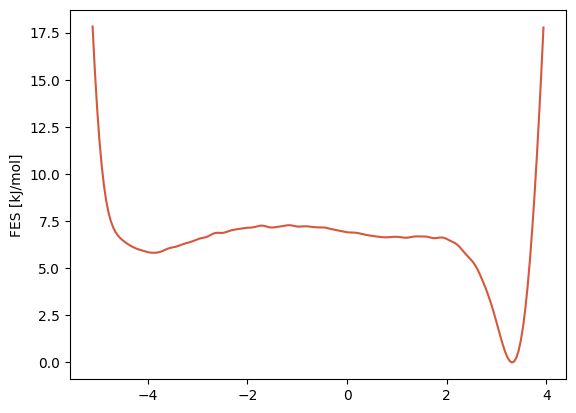

In [ ]:
from mlcolvar.utils.fes import compute_fes
import matplotlib.pyplot as plt
from mlcolvar.utils.plot import paletteFessa
fig,ax=plt.subplots(1,1)
fes,grid,bounds,error = compute_fes(outputs[:,1].cpu().detach().T,
                                    blocks=1,
                                    bandwidth=0.01, scale_by='range',
                                    plot=True, plot_max_fes=20,temp=300,eps=1e-30,ax=ax)

### Load the trajectory

In [19]:
import mdtraj as md
dcd_files = [
    f"/work/tdevergne/bioemu_fun/chignolin/wrapped.xtc"
]

traj = md.load(dcd_files, top="/work/tdevergne/bioemu_fun/chignolin/topology.pdb",stride=1)
ca_indices = traj.topology.select('name CA')

pos_traj = torch.Tensor(traj.xyz[:,ca_indices,:])

### Plot the eigenfunctions, and color the points with respect to the occupation number

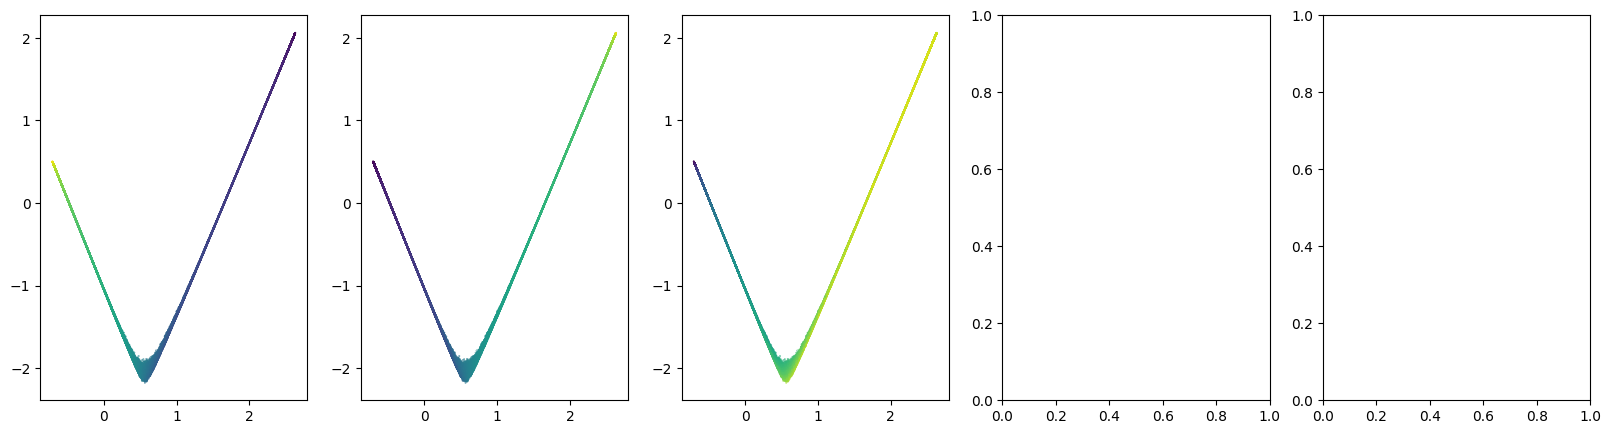

In [20]:
fig, axs = plt.subplots(ncols=5,figsize=(20,5))
for i in range(3):
    axs[i].scatter(eigenfunctions.T[:,1].cpu().detach(),eigenfunctions.T[:,2].cpu().detach(),c=phi[:,i].cpu().detach(),s=0.1)

### Medoid analysis to extract representative structures

In [ ]:
import time
import kmedoids
from sklearn.metrics.pairwise import euclidean_distances

medoids = []
for i in range(3):
    ncluster=5

    mask  = phi[:,i].cpu().detach() > 0.9


    diss = euclidean_distances(smart_dataset["data"].detach()[mask][::100].reshape(-1,10*3))
    print (diss.shape)
    start = time.time()
    # diss = data_d
 
    fp = kmedoids.fasterpam(diss, ncluster)
    print("FasterPAM took: %.2f ms" % ((time.time() - start)*1000))
    print("Loss with FasterPAM:", fp.loss)
    start = time.time()
    pam = kmedoids.pam(diss, ncluster)
    print("PAM took: %.2f ms" % ((time.time() - start)*1000))
    print("Loss with PAM:", pam.loss)


    true_indices = np.flatnonzero(mask)
    # Get the indices corresponding to the nth True values
    result = [true_indices[(n*100).astype(int)] for n in pam.medoids if n <= len(true_indices)]
    medoids.append(result)
    print(f"medoids for class i are {np.array(result)}")

    eig_medoids = eigenfunctions[result]


    plt.scatter(eig_medoids[:,1].detach(),eig_medoids[:,2].detach(),label=f"medoids for class {i}")
plt.legend()

(609, 609)
FasterPAM took: 127.48 ms
Loss with FasterPAM: 144.93230570852757
PAM took: 20.94 ms
Loss with PAM: 146.12260624021292
medoids for class i are [26437  2813 42378 76704 49183]


IndexError: index 42378 is out of bounds for dimension 0 with size 4

In [ ]:
import mdtraj as md
import nglview as nv

subset = traj.slice(medoids[0])

# Superpose them on the first frame
subset.superpose(subset[1])
for i, frame in enumerate(subset):
    frame.save(f'frame_{i}.pdb')

# Load into NGLView
subset.save('five_models.pdb')

# Load into nglview — this will show all models overlaid!
view = nv.show_file('frame_1.pdb')
for i in range(1, 5):
    view.add_component(f'frame_{i}.pdb')

# Style each structure
#view[i].add_cartoon(opacity=0.1)
colors = ['red', 'blue', 'green', 'orange', 'purple']
for i in range(0,5):
    view[i].clear_representations()
    view[i].add_cartoon(opacity=0.5,color='residueindex')


view